**Обучение LSTM-автоэнкодера**

**Этапы:**
1. Формирование скользящих окон (ЭЦН: 60×9, ШГН: 120×9)
2. Обучение LSTM-автоэнкодера (encoder → latent space → decoder)

**Вход:**
- data/processed/ecn_train.csv, ecn_val.csv, ecn_test.csv, scaler_ecn.pkl
- data/processed/shgn_train.csv, shgn_val.csv, shgn_test.csv, scaler_shgn.pkl

**Важно:** Данные ШГН уже объединены (скважины 134+135) и нормализованы одним scaler'ом.

**Выход:**
- models/ecn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)
- models/shgn/ (encoder.pth, decoder.pth, metadata.json, scaler.pkl)

In [2]:
import json
import pickle
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Этап 1: Загрузка данных из /data/processed

In [3]:
DATA_DIR = Path("../data/processed")
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

In [4]:
df_ecn_train = pd.read_csv(DATA_DIR / "ecn_train.csv", parse_dates=["timestamp"])
df_ecn_val = pd.read_csv(DATA_DIR / "ecn_val.csv", parse_dates=["timestamp"])
df_ecn_test = pd.read_csv(DATA_DIR / "ecn_test.csv", parse_dates=["timestamp"])

df_shgn_train = pd.read_csv(DATA_DIR / "shgn_train.csv", parse_dates=["timestamp"])
df_shgn_val = pd.read_csv(DATA_DIR / "shgn_val.csv", parse_dates=["timestamp"])
df_shgn_test = pd.read_csv(DATA_DIR / "shgn_test.csv", parse_dates=["timestamp"])

In [5]:
with open(DATA_DIR / "scaler_ecn.pkl", "rb") as f:
    scaler_ecn = pickle.load(f)

with open(DATA_DIR / "scaler_shgn.pkl", "rb") as f:
    scaler_shgn = pickle.load(f)

In [6]:
print("\nЭЦН:")
print(f"  Train: {len(df_ecn_train):,} точек")
print(f"  Val:   {len(df_ecn_val):,} точек")
print(f"  Test:  {len(df_ecn_test):,} точек")

print("\nШГН (скважины 134+135 объединённые):")
print(f"  Train: {len(df_shgn_train):,} точек")
print(f"  Val:   {len(df_shgn_val):,} точек")
print(f"  Test:  {len(df_shgn_test):,} точек")

print(f"\nПризнаков: {len(FEATURE_COLUMNS)}")
print(f"Колонки: {list(df_ecn_train.columns)}")


ЭЦН:
  Train: 40,770 точек
  Val:   5,091 точек
  Test:  5,096 точек

ШГН (скважины 134+135 объединённые):
  Train: 103,823 точек
  Val:   12,964 точек
  Test:  12,977 точек

Признаков: 9
Колонки: ['us_center', 'us_periph', 'gas_center', 'gas_periph', 'temp', 'water_center', 'water_periph', 'outlet_num', 'gas_integral', 'water_integral', 'timestamp', 'well']


In [7]:
print("\nПроверка нормализации:")
print(
    f"ЭЦН train - mean: {df_ecn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_ecn_train[FEATURE_COLUMNS].std().mean():.3f}"
)
print(
    f"ШГН train - mean: {df_shgn_train[FEATURE_COLUMNS].mean().mean():.3f}, std: {df_shgn_train[FEATURE_COLUMNS].std().mean():.3f}"
)

print("\nПропуски:")
print(f"ЭЦН: {df_ecn_train[FEATURE_COLUMNS].isnull().sum().sum()}")
print(f"ШГН: {df_shgn_train[FEATURE_COLUMNS].isnull().sum().sum()}")


Проверка нормализации:
ЭЦН train - mean: -0.034, std: 1.034
ШГН train - mean: -0.001, std: 1.049

Пропуски:
ЭЦН: 0
ШГН: 0


## Этап 2 — Формирование скользящих окон

Преобразуем временные ряды в матрицы окон для обучения автоэнкодера.

Параметры:
- ЭЦН: окно 60 точек (10 минут), шаг 1 точка (10 сек)
- ШГН: окно 120 точек (20 минут, ~2 цикла по 7 мин), шаг 1 точка (10 сек)

Результат: матрицы 60×9 / 120×9 (время × параметры)

In [8]:
WINDOW_SIZE_ECN = 60
WINDOW_SIZE_SHGN = 120
STEP = 1

def create_sliding_windows(df, feature_columns, window_size, step=1, well_col="well"):
    X = df[feature_columns].values

    well_ids = df[well_col].values if well_col in df.columns else None

    windows = []
    for i in range(0, len(X) - window_size + 1, step):
        if well_ids is not None:
            if len(set(well_ids[i : i + window_size])) > 1:
                continue

        windows.append(X[i : i + window_size])

    return np.array(windows)

In [9]:
print("Формирование окон ЭЦН (60×9)...")
X_ecn_train = create_sliding_windows(df_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_val = create_sliding_windows(df_ecn_val, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)
X_ecn_test = create_sliding_windows(df_ecn_test, FEATURE_COLUMNS, WINDOW_SIZE_ECN, STEP)

print(f"  Train: {X_ecn_train.shape}")
print(f"  Val:   {X_ecn_val.shape}")
print(f"  Test:  {X_ecn_test.shape}")

print("\nФормирование окон ШГН (120×9)...")
X_shgn_train = create_sliding_windows(df_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_val = create_sliding_windows(df_shgn_val, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)
X_shgn_test = create_sliding_windows(df_shgn_test, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, STEP)

print(f"  Train: {X_shgn_train.shape}")
print(f"  Val:   {X_shgn_val.shape}")
print(f"  Test:  {X_shgn_test.shape}")

print("\nПроверка на аномалии:")
print(f"ЭЦН - NaN: {np.isnan(X_ecn_train).sum()}, Inf: {np.isinf(X_ecn_train).sum()}")
print(f"ШГН - NaN: {np.isnan(X_shgn_train).sum()}, Inf: {np.isinf(X_shgn_train).sum()}")


Формирование окон ЭЦН (60×9)...
  Train: (40711, 60, 9)
  Val:   (5032, 60, 9)
  Test:  (5037, 60, 9)

Формирование окон ШГН (120×9)...
  Train: (103585, 120, 9)
  Val:   (12845, 120, 9)
  Test:  (12858, 120, 9)

Проверка на аномалии:
ЭЦН - NaN: 0, Inf: 0
ШГН - NaN: 0, Inf: 0


In [10]:
def plot_random_window(X, feature_columns, window_size, pump_type):
    idx = np.random.randint(0, len(X))
    window = X[idx]

    _, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        axes[i].plot(window[:, i])
        axes[i].set_title(col)
        axes[i].set_xlabel("Время (×10 сек)")
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"{pump_type}: окно #{idx} ({window_size} точек = {window_size // 6} минут)")
    plt.tight_layout()
    plt.show()

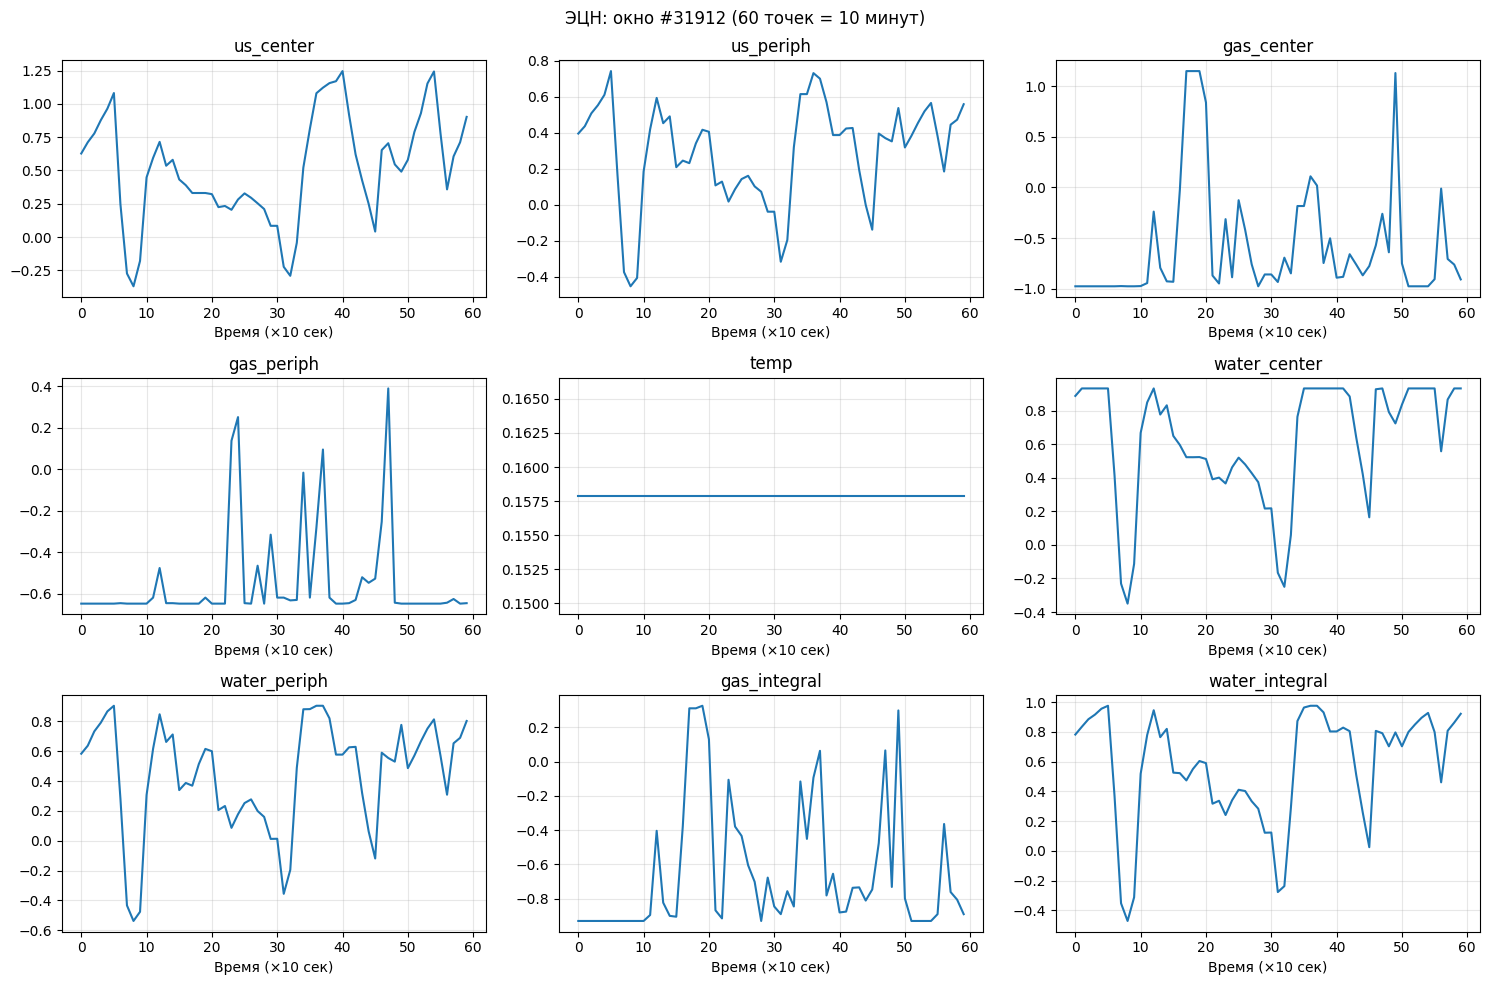

In [15]:
plot_random_window(X_ecn_train, FEATURE_COLUMNS, WINDOW_SIZE_ECN, "ЭЦН")

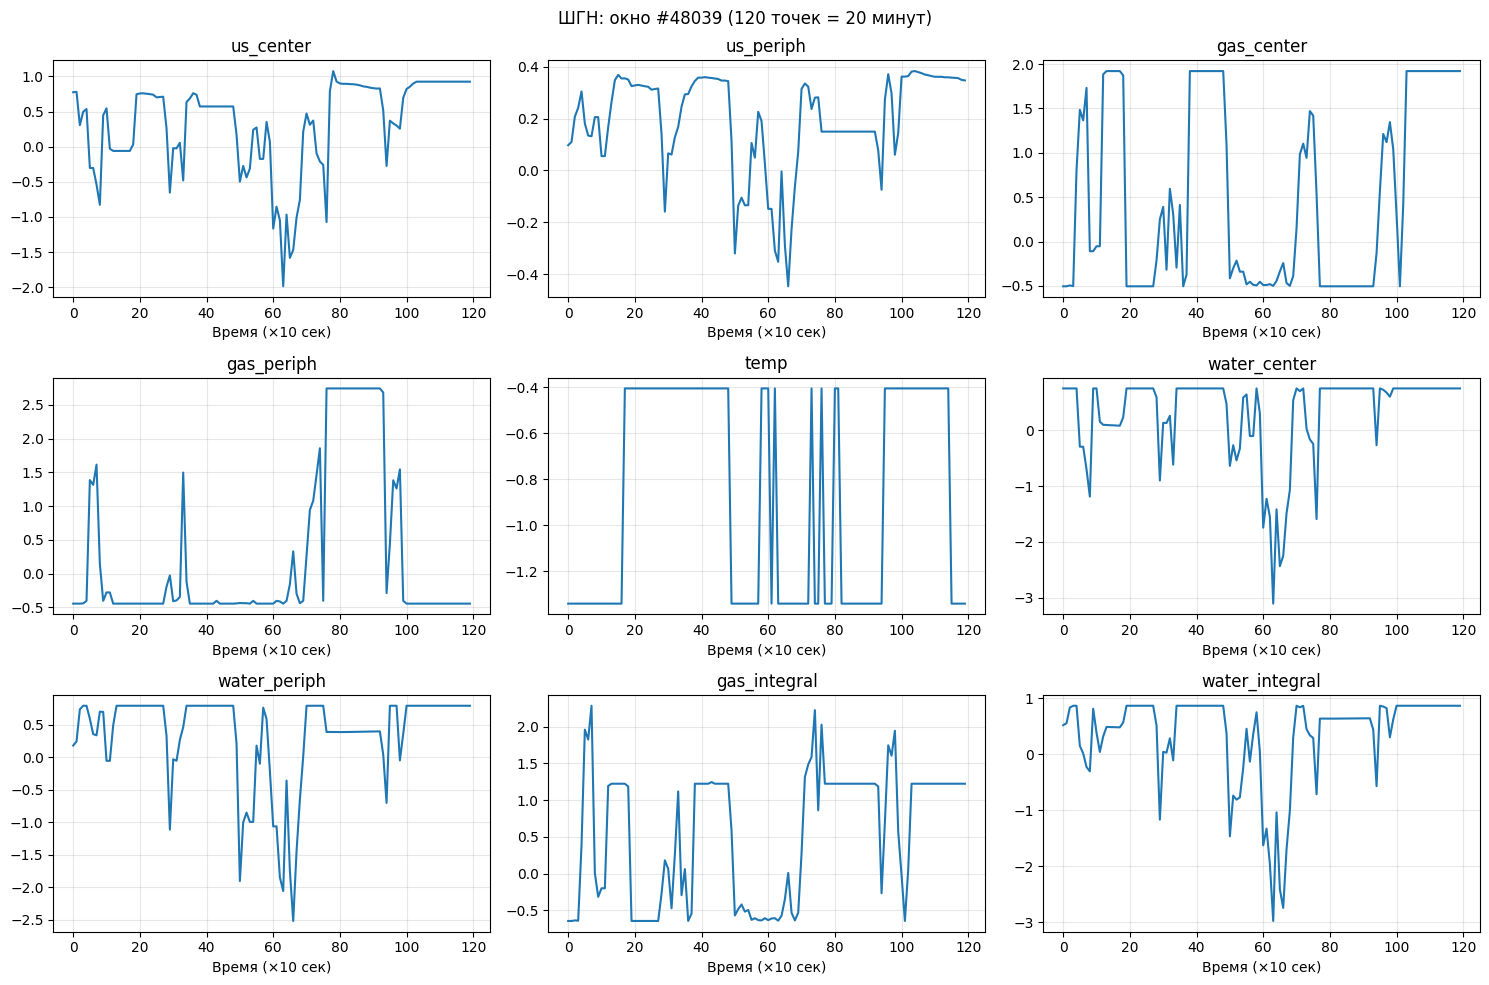

In [16]:
plot_random_window(X_shgn_train, FEATURE_COLUMNS, WINDOW_SIZE_SHGN, "ШГН")

## Этап 3: Обучение LSTM автоэнкодера

### Архитектура
#### Encoder:
- LSTM (2 слоя, 256 нейрона, dropout 0.2)
- Dropout(0.2) на последний hidden state
- Dense (256 → latent_dim)

#### Decoder:
- Dense (latent_dim → h₀ и c₀) — инициализация LSTM из latent
- Dense (latent_dim → 256) + repeat seq_len раз
- LSTM (2 слоя, 256 нейрона, dropout 0.2, начальное состояние h₀/c₀)
- Dropout(0.2) на выход LSTM
- Dense (256 → 9)

#### Параметры
- hidden=256, layers=2, dropout=0.2, batch=64, lr=0.0003, weight_decay=1e-5, grad_clip=1.0
- **latent_dim: ЭЦН=7, ШГН=7** (определено через Elbow Method)

#### Обучение
- Optimizer: AdamW
- Loss: MSE
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Early Stopping: patience=10
- Gradient Clipping: max_norm=1.0

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [ ]:
INPUT_SIZE = 9
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2

BATCH_SIZE = 64
INITIAL_LR = 0.0003
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

MAX_EPOCHS_ELBOW = 50
PATIENCE_LR = 5
PATIENCE_EARLY_STOP = 10

LATENT_DIMS_TO_TEST = [5, 7, 9, 10]

WINDOW_SIZE_ECN = 60
WINDOW_SIZE_SHGN = 120

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True, parents=True)

In [19]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, latent_dim)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        last_hidden = self.dropout(hidden[-1])
        latent = self.fc(last_hidden)
        return latent

In [20]:
class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.fc_hidden = nn.Linear(latent_dim, hidden_size * num_layers)
        self.fc_cell = nn.Linear(latent_dim, hidden_size * num_layers)
        self.fc_input = nn.Linear(latent_dim, hidden_size)

        self.lstm = nn.LSTM(
            hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, z):
        batch_size = z.size(0)

        h0 = self.fc_hidden(z).view(self.num_layers, batch_size, self.hidden_size)
        c0 = self.fc_cell(z).view(self.num_layers, batch_size, self.hidden_size)

        x = self.fc_input(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm(x, (h0, c0))
        x = self.dropout(x)
        x = self.out(x)
        return x

In [21]:
def create_dataloaders(X_train, X_val, X_test, batch_size):
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(X_val))
    test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(X_test))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


train_loader_ecn, val_loader_ecn, test_loader_ecn = create_dataloaders(X_ecn_train, X_ecn_val, X_ecn_test, BATCH_SIZE)

train_loader_shgn, val_loader_shgn, test_loader_shgn = create_dataloaders(
    X_shgn_train, X_shgn_val, X_shgn_test, BATCH_SIZE
)

print(f"ЭЦН: {len(train_loader_ecn)} батчей в train")
print(f"ШГН: {len(train_loader_shgn)} батчей в train")

ЭЦН: 637 батчей в train
ШГН: 1619 батчей в train


In [22]:
def train_epoch(encoder, decoder, train_loader, optimizer, criterion, grad_clip_norm, device):
    encoder.train()
    decoder.train()

    total_loss = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_size = batch_x.size(0)

        optimizer.zero_grad()

        latent = encoder(batch_x)
        reconstructed = decoder(latent)

        loss = criterion(reconstructed, batch_y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), grad_clip_norm)

        optimizer.step()

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [23]:
def validate(encoder, decoder, val_loader, criterion, device):
    encoder.eval()
    decoder.eval()

    total_loss = 0
    total_samples = 0
    mse_per_feature = torch.zeros(INPUT_SIZE)

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            batch_size = batch_x.size(0)

            latent = encoder(batch_x)
            reconstructed = decoder(latent)

            loss = criterion(reconstructed, batch_y)
            total_loss += loss.item() * batch_size

            mse_batch = ((reconstructed - batch_y) ** 2).mean(dim=(0, 1)).cpu()
            mse_per_feature += mse_batch * batch_size

            total_samples += batch_size

    mse_per_feature /= total_samples
    return total_loss / total_samples, mse_per_feature

In [24]:
def train_model(
    encoder,
    decoder,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay,
    patience_lr,
    patience_early_stop,
    grad_clip_norm,
    device,
    save_path=None,
):

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        list(encoder.parameters()) + list(decoder.parameters()), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=patience_lr, min_lr=1e-6
    )

    best_val_loss = float("inf")
    best_mse_per_feature = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        train_loss = train_epoch(encoder, decoder, train_loader, optimizer, criterion, grad_clip_norm, device)
        val_loss, mse_per_feature = validate(encoder, decoder, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        print(
            f"Эпоха {epoch + 1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.6f}"
        )

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mse_per_feature = mse_per_feature
            patience_counter = 0
            if save_path:
                torch.save(encoder.state_dict(), save_path / "encoder.pth")
                torch.save(decoder.state_dict(), save_path / "decoder.pth")
        else:
            patience_counter += 1

        if patience_counter >= patience_early_stop:
            print(f"Early stopping на эпохе {epoch + 1}")
            break

    return best_val_loss, best_mse_per_feature, history

In [25]:
def elbow_method(train_loader, val_loader, latent_dims, seq_len, pump_type, device):
    results = []

    for latent_dim in latent_dims:
        print(f"\n{'=' * 60}")
        print(f"{pump_type}: Обучение с latent_dim = {latent_dim}")
        print(f"{'=' * 60}")

        encoder = LSTMEncoder(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, latent_dim, DROPOUT).to(device)
        decoder = LSTMDecoder(latent_dim, HIDDEN_SIZE, NUM_LAYERS, INPUT_SIZE, seq_len, DROPOUT).to(device)

        best_val_loss, best_mse_per_feature, _ = train_model(
            encoder,
            decoder,
            train_loader,
            val_loader,
            epochs=MAX_EPOCHS_ELBOW,
            lr=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            patience_lr=PATIENCE_LR,
            patience_early_stop=PATIENCE_EARLY_STOP,
            grad_clip_norm=GRAD_CLIP_NORM,
            device=device,
            save_path=None,
        )

        results.append(
            {
                "latent_dim": latent_dim,
                "best_val_loss": best_val_loss,
                "mse_per_feature": best_mse_per_feature.numpy(),
                "encoder": encoder,
                "decoder": decoder,
            }
        )

        print(f"\nЛучший val_loss: {best_val_loss:.6f}")

    return results

In [26]:
def plot_elbow_results(results, pump_type):
    latent_dims = [r["latent_dim"] for r in results]
    val_losses = [r["best_val_loss"] for r in results]

    _, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(latent_dims, val_losses, marker="o", linewidth=2, markersize=8)
    axes[0].set_xlabel("Latent Dimension")
    axes[0].set_ylabel("Best Val Loss (MSE)")
    axes[0].set_title(f"{pump_type}: Elbow Method")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(latent_dims)

    mse_per_feature_all = [r["mse_per_feature"] for r in results]
    for i, feature in enumerate(FEATURE_COLUMNS):
        mse_values = [mse[i] for mse in mse_per_feature_all]
        axes[1].plot(latent_dims, mse_values, marker="o", label=feature)

    axes[1].set_xlabel("Latent Dimension")
    axes[1].set_ylabel("MSE по признакам")
    axes[1].set_title(f"{pump_type}: MSE по каждому признаку")
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(latent_dims)

    plt.tight_layout()
    plt.show()

In [27]:
def plot_reconstruction_comparison(results, X_val, pump_type, device):
    idx = np.random.randint(0, len(X_val))
    sample = torch.FloatTensor(X_val[idx : idx + 1]).to(device)

    reconstructions = []
    for result in results:
        encoder = result["encoder"].eval()
        decoder = result["decoder"].eval()

        with torch.no_grad():
            latent = encoder(sample)
            reconstructed = decoder(latent)

        reconstructions.append({"latent_dim": result["latent_dim"], "reconstructed": reconstructed[0].cpu().numpy()})

    _, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, feature in enumerate(FEATURE_COLUMNS):
        axes[i].plot(sample[0, :, i].cpu().numpy(), label="Оригинал", linewidth=2, alpha=0.7)

        for recon in reconstructions:
            axes[i].plot(
                recon["reconstructed"][:, i], label=f"latent_dim={recon['latent_dim']}", linestyle="--", alpha=0.7
            )

        axes[i].set_title(feature)
        axes[i].set_xlabel("Время (×10 сек)")
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"{pump_type}: Сравнение reconstruction для окна #{idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

ШАГ 1: ПОДБОР LATENT_DIM ДЛЯ ЭЦН

ЭЦН: Обучение с latent_dim = 5
Эпоха 1/50 | Train Loss: 0.367842 | Val Loss: 0.253130 | LR: 0.000300
Эпоха 2/50 | Train Loss: 0.287012 | Val Loss: 0.242036 | LR: 0.000300
Эпоха 3/50 | Train Loss: 0.277791 | Val Loss: 0.244452 | LR: 0.000300
Эпоха 4/50 | Train Loss: 0.264344 | Val Loss: 0.236423 | LR: 0.000300
Эпоха 5/50 | Train Loss: 0.240357 | Val Loss: 0.223723 | LR: 0.000300
Эпоха 6/50 | Train Loss: 0.224297 | Val Loss: 0.215628 | LR: 0.000300
Эпоха 7/50 | Train Loss: 0.207151 | Val Loss: 0.196835 | LR: 0.000300
Эпоха 8/50 | Train Loss: 0.192720 | Val Loss: 0.195908 | LR: 0.000300
Эпоха 9/50 | Train Loss: 0.175162 | Val Loss: 0.182216 | LR: 0.000300
Эпоха 10/50 | Train Loss: 0.161016 | Val Loss: 0.177393 | LR: 0.000300
Эпоха 11/50 | Train Loss: 0.156984 | Val Loss: 0.171321 | LR: 0.000300
Эпоха 12/50 | Train Loss: 0.153130 | Val Loss: 0.169682 | LR: 0.000300
Эпоха 13/50 | Train Loss: 0.144076 | Val Loss: 0.172412 | LR: 0.000300
Эпоха 14/50 | Train L

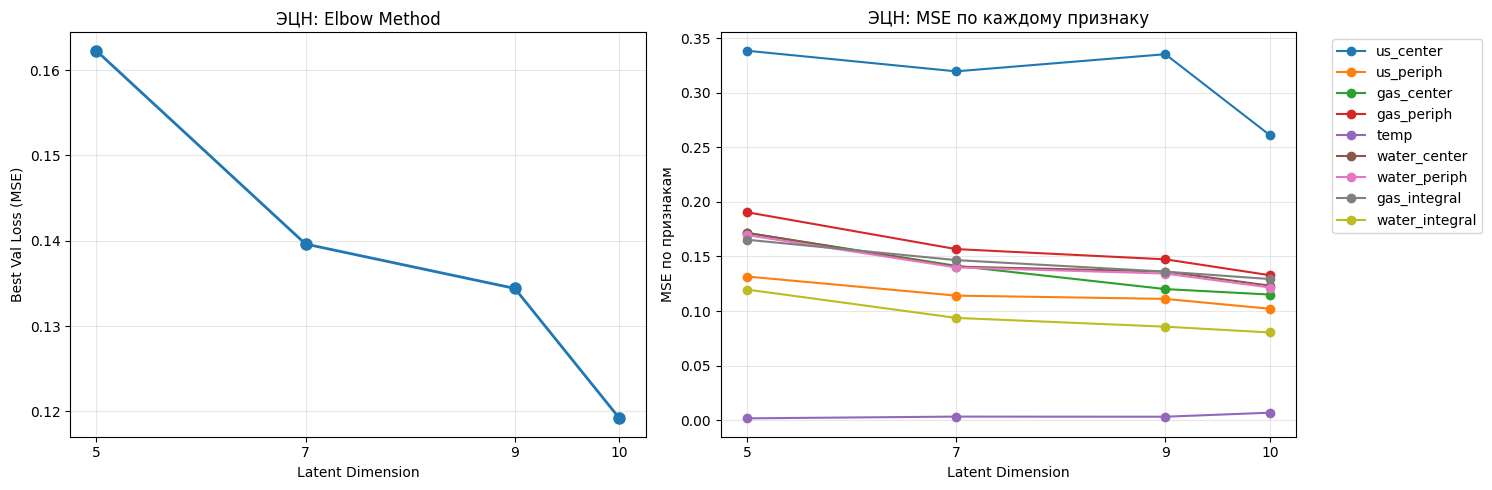

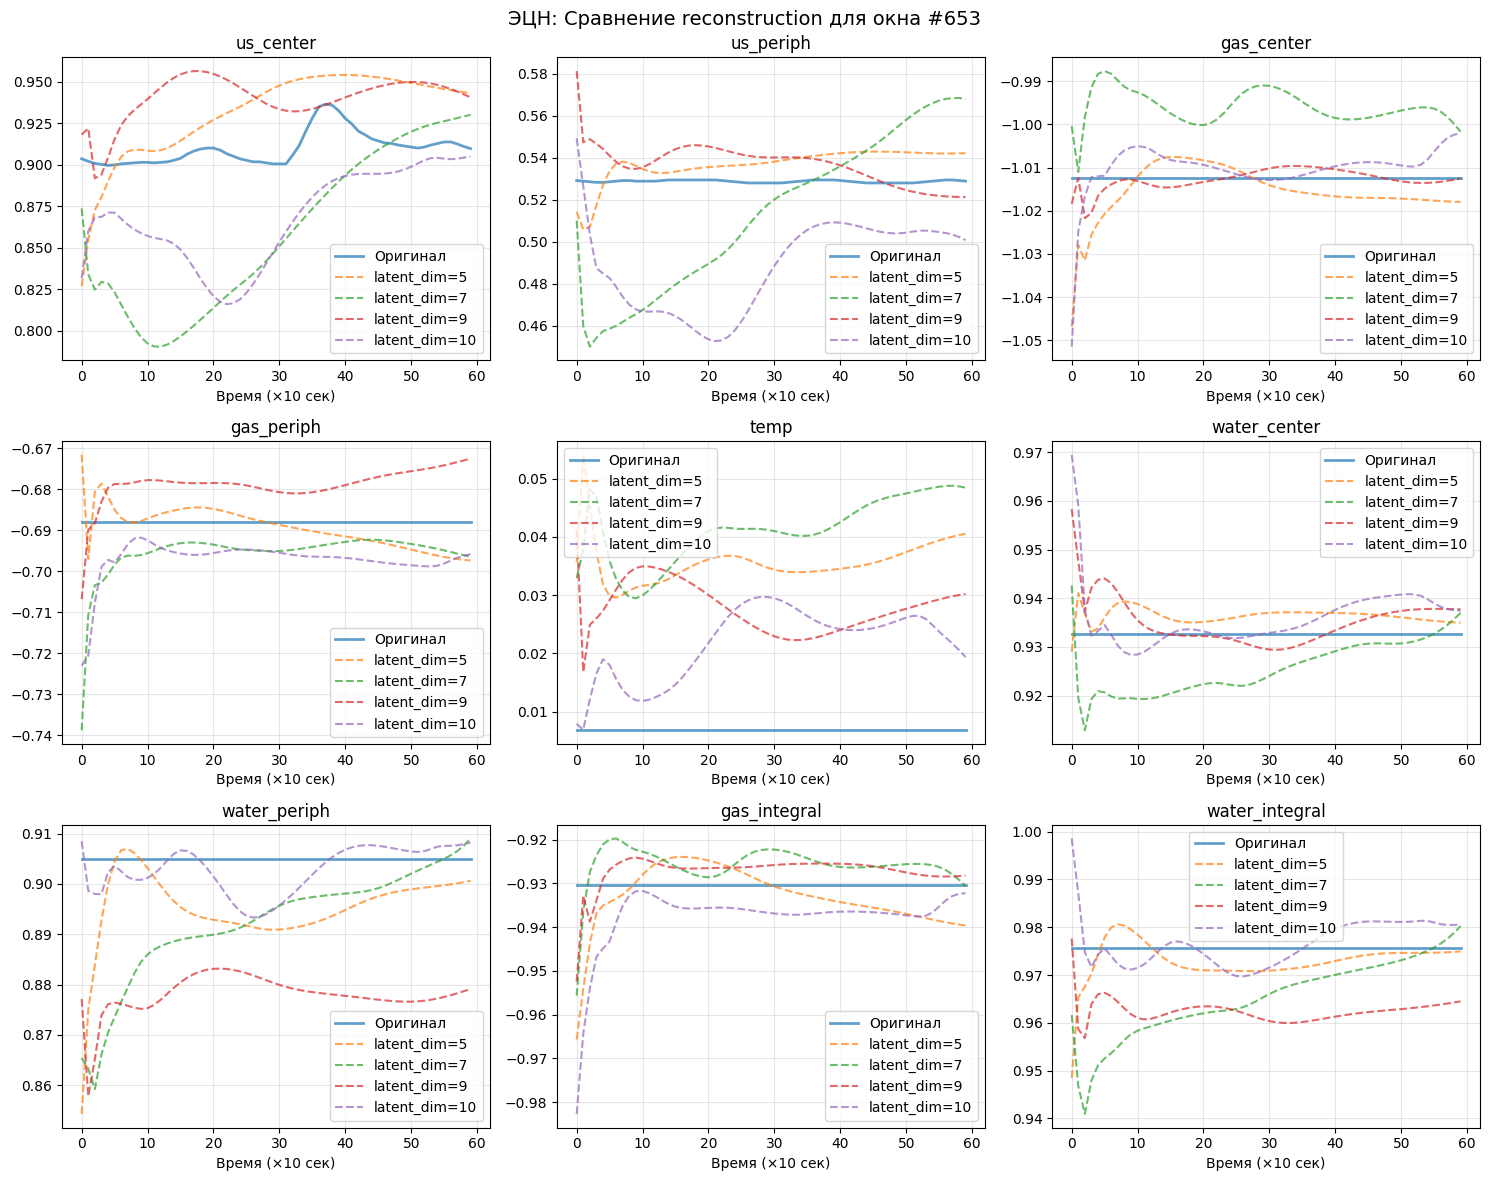

In [ ]:
print("ШАГ 1: ПОДБОР LATENT_DIM ДЛЯ ЭЦН")
results_ecn = elbow_method(train_loader_ecn, val_loader_ecn, LATENT_DIMS_TO_TEST, WINDOW_SIZE_ECN, "ЭЦН", device)

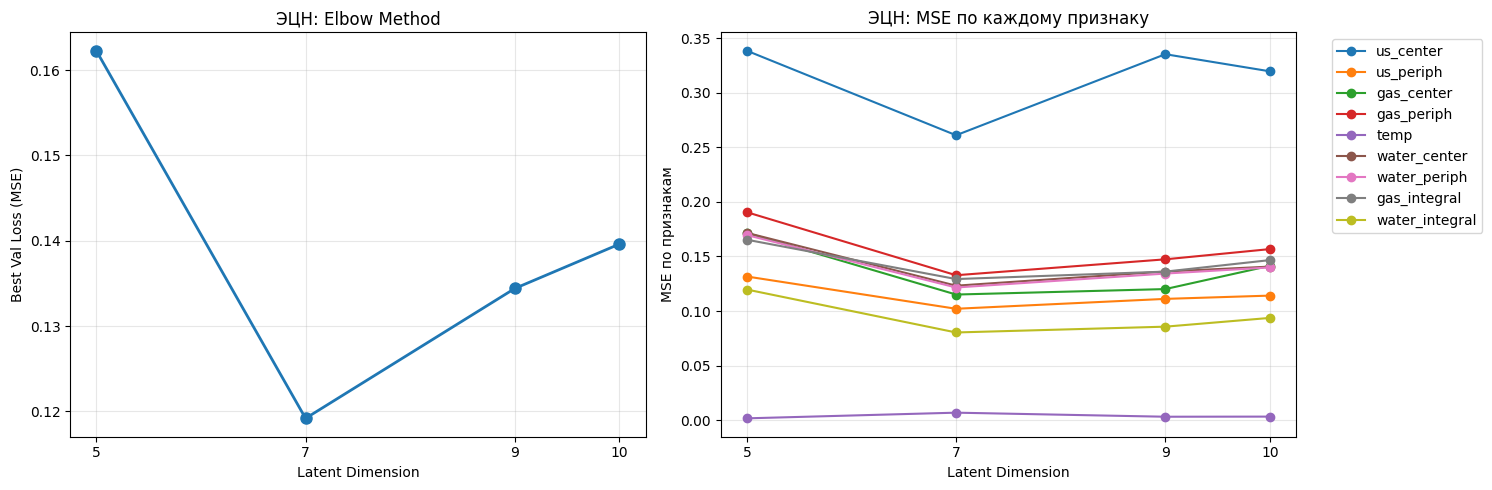

In [140]:
plot_elbow_results(results_ecn, "ЭЦН")

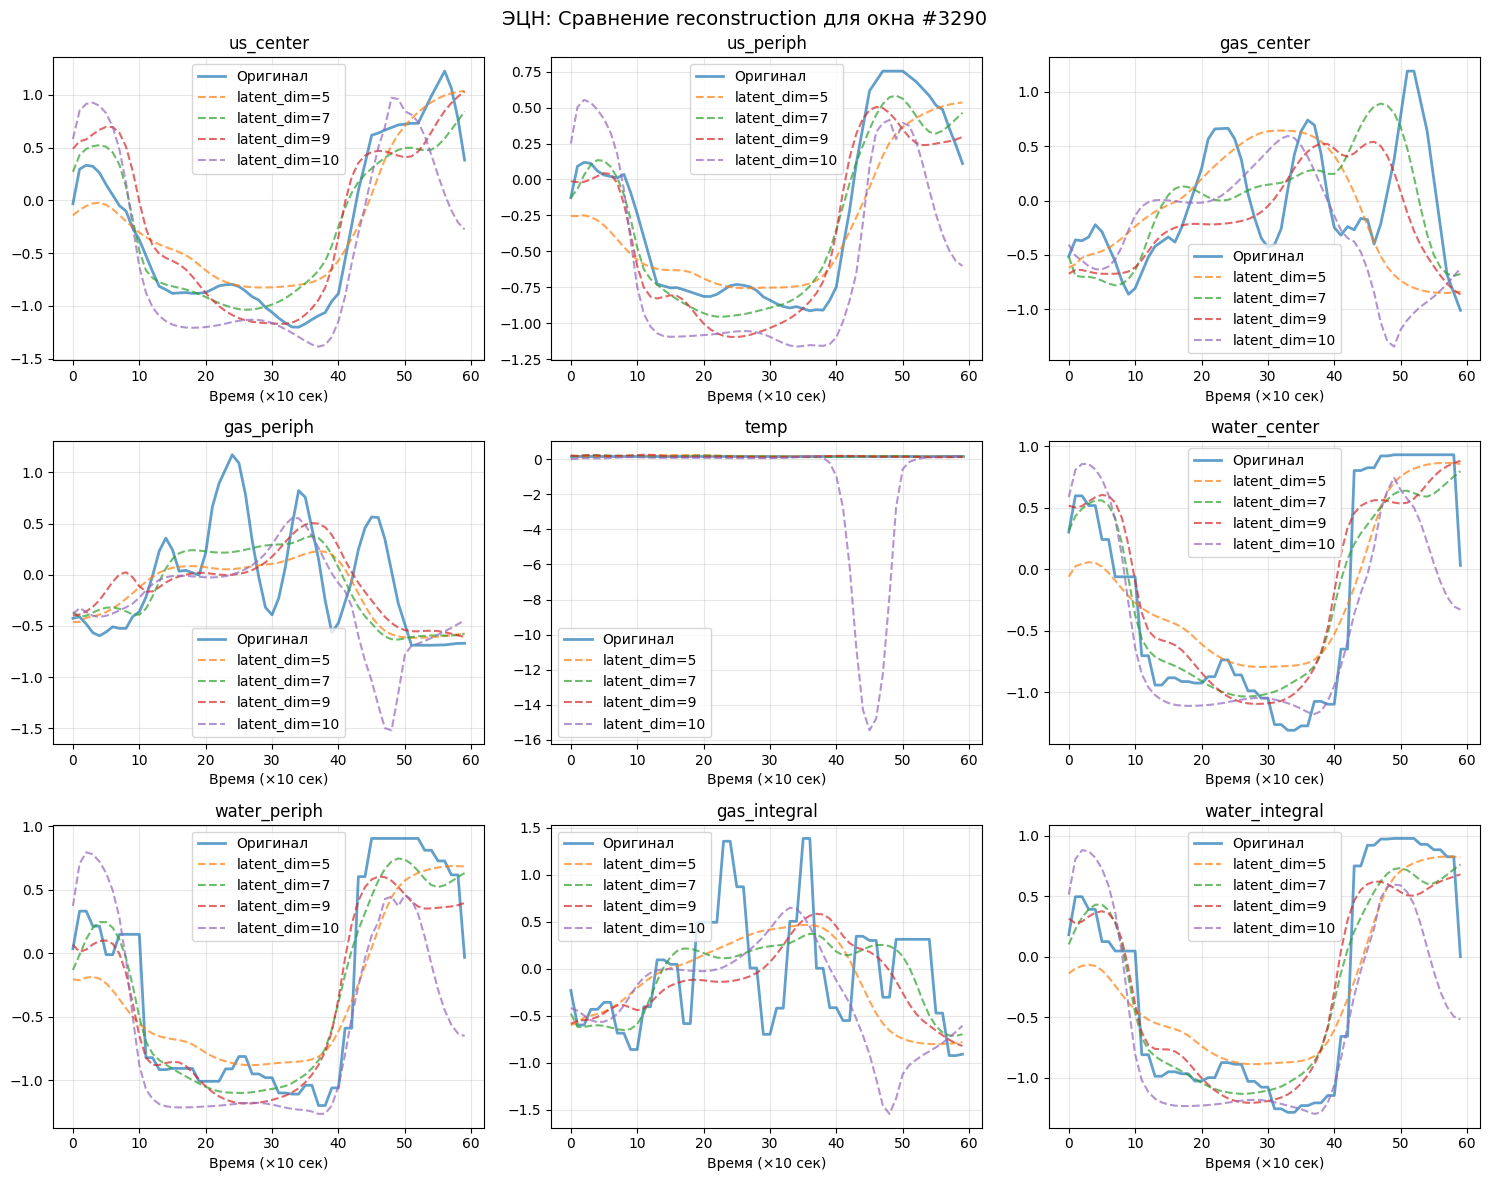

In [ ]:
plot_reconstruction_comparison(results_ecn, X_ecn_val, "ЭЦН", device)

In [142]:
best_ecn = min(results_ecn, key=lambda r: r["best_val_loss"])
LATENT_DIM_ECN = best_ecn["latent_dim"]

print(f"\n{'=' * 60}")
print(f"Выбран оптимальный latent_dim для ЭЦН: {LATENT_DIM_ECN}")
print(f"Val Loss: {best_ecn['best_val_loss']:.6f}")
print(f"{'=' * 60}")


Выбран оптимальный latent_dim для ЭЦН: 7
Val Loss: 0.119186


## Выбор оптимального latent_dim для ЭЦН

### Результаты Elbow Method:

| latent_dim | Val Loss | Compression Ratio | Изменение |
|------------|----------|-------------------|-----------|
| 5 | 0.162 | 108× | baseline |
| **7** | **0.119** | **77×** | **-27%** ✅ |
| 9 | 0.134 | 60× | +13% |
| 10 | 0.140 | 54× | +18% |

### Обоснование выбора latent_dim=7:

**1. Минимальный val_loss**
- Лучший результат среди всех протестированных значений
- На 27% лучше latent_dim=5
- На 13% лучше latent_dim=9
- На 18% лучше latent_dim=10

**2. Сильное сжатие**
- Compression ratio = 77× (540 параметров → 7)
- Компактное латентное пространство для эффективной кластеризации

**3. Точка оптимума**
- Дальнейшее увеличение размерности ухудшает результат
- latent_dim=9-10 показывают признаки переобучения

**4. Интерпретируемость**
- 7 измерений кодируют:
  - 4-5 базовых параметров (УЗ, температура, обводнённость, газ)
  - 2-3 фазовых состояния

**Вывод:** latent_dim=7 обеспечивает оптимальный баланс между качеством reconstruction и степенью сжатия.

In [146]:
ecn_save_path = MODELS_DIR / "ecn"
ecn_save_path.mkdir(exist_ok=True, parents=True)

best_ecn_result = min(results_ecn, key=lambda r: r["best_val_loss"])

torch.save(best_ecn_result["encoder"].state_dict(), ecn_save_path / "encoder.pth")
torch.save(best_ecn_result["decoder"].state_dict(), ecn_save_path / "decoder.pth")

shutil.copy(DATA_DIR / "scaler_ecn.pkl", ecn_save_path / "scaler.pkl")

metadata_ecn = {
    "latent_dim": LATENT_DIM_ECN,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "window_size": WINDOW_SIZE_ECN,
    "best_val_loss": best_ecn_result["best_val_loss"],
    "input_size": INPUT_SIZE,
}

with open(ecn_save_path / "metadata.json", "w") as f:
    json.dump(metadata_ecn, f, indent=2)

print(f"\nМодель ЭЦН сохранена в {ecn_save_path}")
print("  - encoder.pth")
print("  - decoder.pth")
print("  - scaler.pkl")
print("  - metadata.json")


Модель ЭЦН сохранена в ..\models\ecn
  - encoder.pth
  - decoder.pth
  - scaler.pkl
  - metadata.json


In [28]:
print("ШАГ 2: ПОДБОР LATENT_DIM ДЛЯ ШГН")

results_shgn = elbow_method(train_loader_shgn, val_loader_shgn, LATENT_DIMS_TO_TEST, WINDOW_SIZE_SHGN, "ШГН", device)

ШАГ 2: ПОДБОР LATENT_DIM ДЛЯ ШГН

ШГН: Обучение с latent_dim = 5
Эпоха 1/30 | Train Loss: 0.941394 | Val Loss: 0.228869 | LR: 0.000300
Эпоха 2/30 | Train Loss: 0.905287 | Val Loss: 0.235420 | LR: 0.000300
Эпоха 3/30 | Train Loss: 0.818459 | Val Loss: 0.235603 | LR: 0.000300
Эпоха 4/30 | Train Loss: 0.785640 | Val Loss: 0.238185 | LR: 0.000300
Эпоха 5/30 | Train Loss: 0.767705 | Val Loss: 0.235531 | LR: 0.000300
Эпоха 6/30 | Train Loss: 0.753625 | Val Loss: 0.235025 | LR: 0.000300
Эпоха 7/30 | Train Loss: 0.744999 | Val Loss: 0.237938 | LR: 0.000300
Эпоха 8/30 | Train Loss: 0.718812 | Val Loss: 0.236481 | LR: 0.000150
Эпоха 9/30 | Train Loss: 0.711728 | Val Loss: 0.234276 | LR: 0.000150
Эпоха 10/30 | Train Loss: 0.706070 | Val Loss: 0.231962 | LR: 0.000150
Эпоха 11/30 | Train Loss: 0.700963 | Val Loss: 0.234249 | LR: 0.000150
Early stopping на эпохе 11

Лучший val_loss: 0.228869

ШГН: Обучение с latent_dim = 7
Эпоха 1/30 | Train Loss: 0.945326 | Val Loss: 0.230885 | LR: 0.000300
Эпоха 2

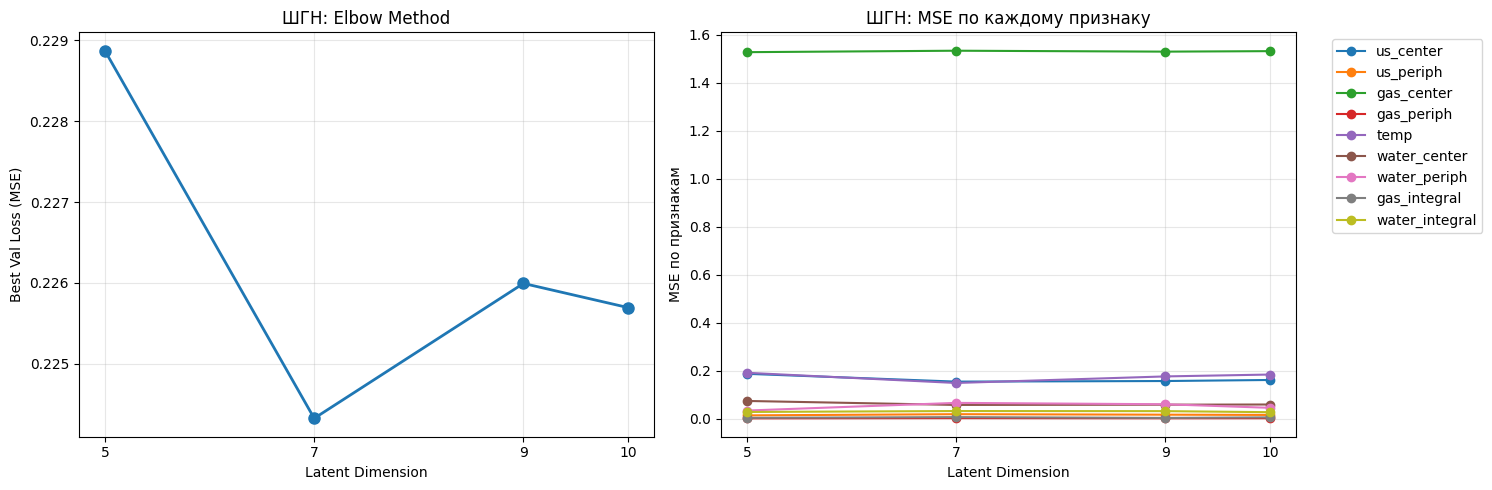

In [44]:
plot_elbow_results(results_shgn, "ШГН")

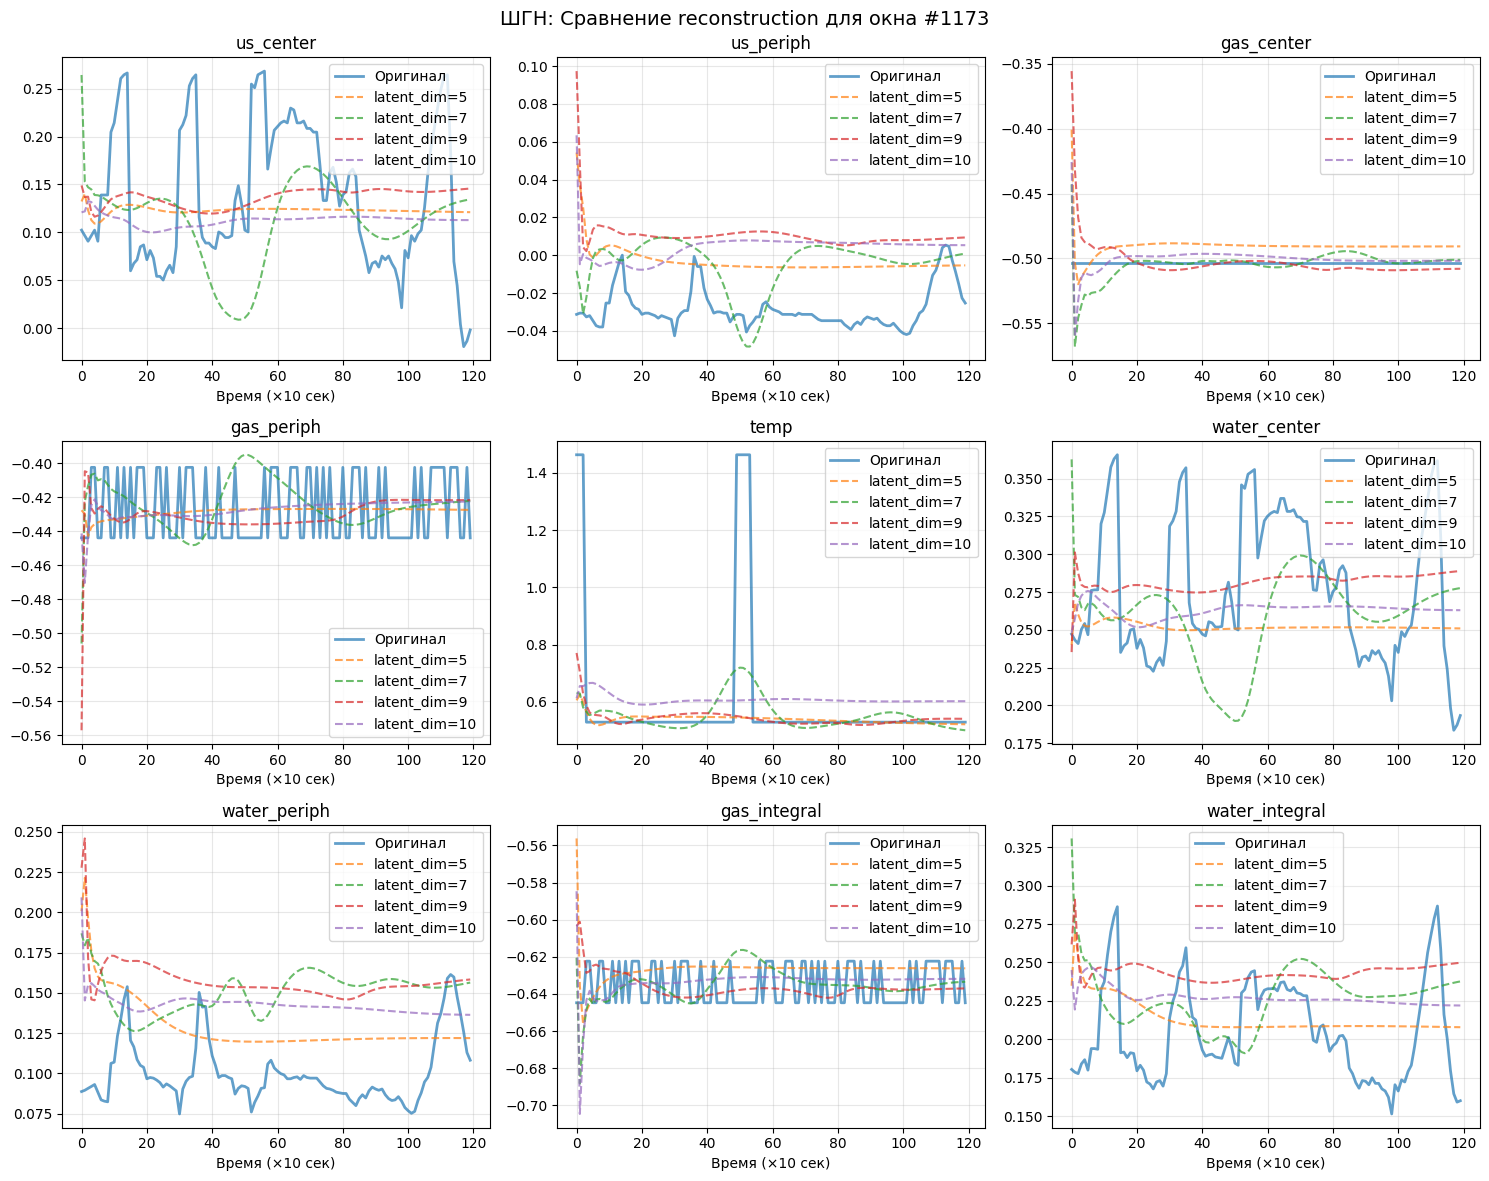

In [115]:
plot_reconstruction_comparison(results_shgn, X_shgn_val, "ШГН", device)

In [57]:
best_shgn = min(results_shgn, key=lambda r: r["best_val_loss"])
LATENT_DIM_SHGN = best_shgn["latent_dim"]

print(f"\n{'=' * 60}")
print(f"Выбран оптимальный latent_dim для ШГН: {LATENT_DIM_SHGN}")
print(f"Val Loss: {best_shgn['best_val_loss']:.6f}")
print(f"{'=' * 60}")


Выбран оптимальный latent_dim для ШГН: 7
Val Loss: 0.224328


In [59]:
shgn_save_path = MODELS_DIR / "shgn"
shgn_save_path.mkdir(exist_ok=True, parents=True)

best_shgn_result = min(results_shgn, key=lambda r: r["best_val_loss"])

torch.save(best_shgn_result["encoder"].state_dict(), shgn_save_path / "encoder.pth")
torch.save(best_shgn_result["decoder"].state_dict(), shgn_save_path / "decoder.pth")

shutil.copy(DATA_DIR / "scaler_shgn.pkl", shgn_save_path / "scaler.pkl")

metadata_ecn = {
    "latent_dim": LATENT_DIM_SHGN,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "window_size": WINDOW_SIZE_SHGN,
    "best_val_loss": best_shgn_result["best_val_loss"],
    "input_size": INPUT_SIZE,
}

with open(shgn_save_path / "metadata.json", "w") as f:
    json.dump(metadata_ecn, f, indent=2)

print(f"\nМодель ШГН сохранена в {shgn_save_path}")
print("  - encoder.pth")
print("  - decoder.pth")
print("  - scaler.pkl")
print("  - metadata.json")


Модель ШГН сохранена в ..\models\shgn
  - encoder.pth
  - decoder.pth
  - scaler.pkl
  - metadata.json
